In [2]:
# ============================================================
# Machine Learning Model Development
# Hemoglobinopathy Classification
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Scikit-Learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:

path = "/content/drive/MyDrive/Colab Notebooks/Dr_Abdullah/Hemoglobinopathy_Final_Preprocessed.xlsx"



In [5]:
# ============================================================
# Load Final Preprocessed Dataset
# ============================================================

df = pd.read_excel(path)

print("="*60)
print("DATASET LOADED")
print("="*60)

print("Shape :", df.shape)

print("\nMissing Values")
print(df.isnull().sum().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

display(df.head())

DATASET LOADED
Shape : (1539, 15)

Missing Values
0

Duplicate Records
2


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Results,Hospital
0,32.0,Male,94.6,5.4,0.0,0.0,0.0,6.79,13.3,47.3,69.7,19.7,28.2,Beta Thalassemia Minor,KTH
1,21.0,Female,98.0,2.0,0.0,0.0,0.0,3.88,8.6,29.5,76.0,24.0,31.0,Normal,KTH
2,30.0,Female,97.0,2.1,0.0,0.0,0.0,3.96,7.9,27.8,70.1,19.9,28.4,Normal,KTH
3,2.0,Female,94.3,5.7,0.0,0.0,0.0,6.26,11.8,36.2,57.8,18.8,32.5,Beta Thalassemia Minor,KTH
4,37.0,Female,94.7,5.4,0.0,0.0,0.0,4.42,8.2,27.1,61.4,18.5,30.1,Beta Thalassemia Minor,KTH


In [6]:
# ============================================================
# Encode Categorical Variables
# ============================================================

gender_encoder = LabelEncoder()
hospital_encoder = LabelEncoder()
target_encoder = LabelEncoder()

df["Gender"] = gender_encoder.fit_transform(df["Gender"])

df["Hospital"] = hospital_encoder.fit_transform(df["Hospital"])

df["Results"] = target_encoder.fit_transform(df["Results"])

print("Encoding Completed\n")

print("Gender Classes")
print(dict(zip(gender_encoder.classes_,
               gender_encoder.transform(gender_encoder.classes_))))

print("\nHospital Classes")
print(dict(zip(hospital_encoder.classes_,
               hospital_encoder.transform(hospital_encoder.classes_))))

print("\nTarget Classes")
print(dict(zip(target_encoder.classes_,
               target_encoder.transform(target_encoder.classes_))))

Encoding Completed

Gender Classes
{'Female': np.int64(0), 'Male': np.int64(1)}

Hospital Classes
{'KTH': np.int64(0), 'Mardan': np.int64(1)}

Target Classes
{'Beta Thalassemia Major': np.int64(0), 'Beta Thalassemia Minor': np.int64(1), 'Borderline HbA2': np.int64(2), 'Hb D Trait': np.int64(3), 'Normal': np.int64(4), 'Sickle Disorders': np.int64(5)}


In [7]:
# ============================================================
# Define Features and Target
# ============================================================

X = df.drop(columns=["Results"])

y = df["Results"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (1539, 14)
Target Shape : (1539,)


In [8]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Class Distribution")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution")
print(y_test.value_counts().sort_index())

TRAIN TEST SPLIT
Training Samples : 1231
Testing Samples  : 308

Training Class Distribution
Results
0     17
1    280
2     18
3      8
4    894
5     14
Name: count, dtype: int64

Testing Class Distribution
Results
0      5
1     70
2      4
3      2
4    224
5      3
Name: count, dtype: int64


In [9]:
# ============================================================
# Feature Scaling
# ============================================================

numerical_features = [
    "Age",
    "Hb-A",
    "HB-A2",
    "Hb-F",
    "Hb-S",
    "Hb-D",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [10]:
# ============================================================
# Define Features and Target
# ============================================================

X = df.drop(columns=["Results"])
y = df["Results"]

print("="*60)
print("FEATURE MATRIX")
print("="*60)

print("X Shape :", X.shape)
print("y Shape :", y.shape)

print("\nFeatures")
print(list(X.columns))

FEATURE MATRIX
X Shape : (1539, 14)
y Shape : (1539,)

Features
['Age', 'Gender', 'Hb-A', 'HB-A2', 'Hb-F', 'Hb-S', 'Hb-D', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'Hospital']


In [11]:
# ============================================================
# Train-Test Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nTraining Class Distribution")
print(y_train.value_counts().sort_index())

print("\nTesting Class Distribution")
print(y_test.value_counts().sort_index())

TRAIN TEST SPLIT
Training Samples : 1231
Testing Samples  : 308

Training Class Distribution
Results
0     17
1    280
2     18
3      8
4    894
5     14
Name: count, dtype: int64

Testing Class Distribution
Results
0      5
1     70
2      4
3      2
4    224
5      3
Name: count, dtype: int64


In [12]:
!pip install imbalanced-learn

In [13]:
# ============================================================
# Handle Class Imbalance using SMOTE
# ============================================================

from imblearn.over_sampling import SMOTE

print("="*60)
print("CLASS DISTRIBUTION BEFORE SMOTE")
print("="*60)
print(y_train.value_counts().sort_index())

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n" + "="*60)
print("CLASS DISTRIBUTION AFTER SMOTE")
print("="*60)
print(y_train_smote.value_counts().sort_index())

print("\nTraining Shape Before SMOTE :", X_train.shape)
print("Training Shape After SMOTE  :", X_train_smote.shape)

CLASS DISTRIBUTION BEFORE SMOTE
Results
0     17
1    280
2     18
3      8
4    894
5     14
Name: count, dtype: int64

CLASS DISTRIBUTION AFTER SMOTE
Results
0    894
1    894
2    894
3    894
4    894
5    894
Name: count, dtype: int64

Training Shape Before SMOTE : (1231, 14)
Training Shape After SMOTE  : (5364, 14)


In [14]:
# ============================================================
# Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

numerical_features = [
    "Age",
    "Hb-A",
    "HB-A2",
    "Hb-F",
    "Hb-S",
    "Hb-D",
    "RBC",
    "HGB",
    "HCT",
    "MCV",
    "MCH",
    "MCHC"
]

scaler = StandardScaler()

# Copy data
X_train_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()

# Scale only numerical variables
X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train_smote[numerical_features]
)

X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("="*60)
print("FEATURE SCALING COMPLETED")
print("="*60)

print("Training Shape :", X_train_scaled.shape)
print("Testing Shape  :", X_test_scaled.shape)

display(X_train_scaled.head())

FEATURE SCALING COMPLETED
Training Shape : (5364, 14)
Testing Shape  : (308, 14)


,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Hospital
0,0.020767,0,0.891466,-0.218524,-0.553761,-0.359033,-0.480673,0.085291,1.720013,1.852188,1.335468,1.345199,0.993812,0
1,0.401699,0,0.900490,-0.451480,-0.553761,-0.359033,-0.480673,-0.154825,0.010610,-0.116956,1.957396,1.521378,0.463557,0
2,0.325513,0,0.783169,1.800429,-0.521236,-0.359033,-0.480673,0.164263,0.589177,1.066743,-0.393795,-0.539913,-0.390742,1
3,-1.274405,1,0.915532,-0.839741,-0.553761,-0.359033,-0.480673,-0.069450,-1.278017,-1.355968,-1.925861,-1.949343,-1.745837,0
4,-1.350592,1,0.882441,-0.684436,-0.524489,-0.359033,-0.480673,0.111971,-0.489061,-0.415646,-1.774171,-1.544132,-0.685328,1


In [15]:
# ============================================================
# Stratified Cross Validation
# ============================================================

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [16]:
# ============================================================
# Model Evaluation Function
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    roc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr"
    )

    print("="*60)
    print(model.__class__.__name__)
    print("="*60)

    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1 Score          : {f1:.4f}")
    print(f"MCC               : {mcc:.4f}")
    print(f"Cohen Kappa       : {kappa:.4f}")
    print(f"ROC-AUC           : {roc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(model.__class__.__name__)
    plt.show()

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc,
        "Kappa": kappa,
        "ROC-AUC": roc
    }

LogisticRegression
Accuracy          : 0.8571
Balanced Accuracy : 0.8807
Precision         : 0.9502
Recall            : 0.8571
F1 Score          : 0.8961
MCC               : 0.7300
Cohen Kappa       : 0.7092
ROC-AUC           : 0.9802

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.94      0.89      0.91        70
           2       0.09      0.75      0.15         4
           3       0.67      1.00      0.80         2
           4       0.98      0.85      0.91       224
           5       1.00      1.00      1.00         3

    accuracy                           0.86       308
   macro avg       0.71      0.88      0.74       308
weighted avg       0.95      0.86      0.90       308



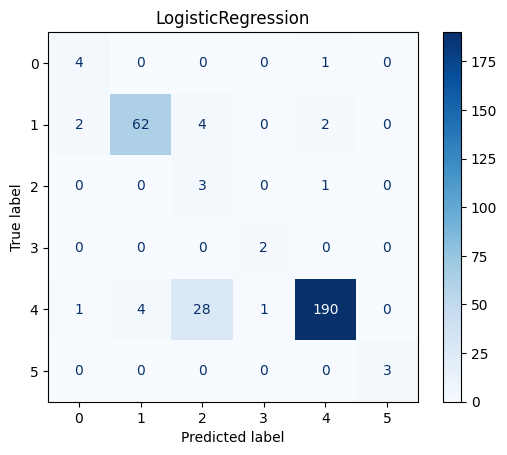

In [17]:
# ============================================================
# Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr_results = evaluate_model(
    lr,
    X_train_scaled,
    X_test_scaled,
    y_train_smote,
    y_test
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00
Logistic Regression
LogisticRegression
Accuracy          : 0.8571
Balanced Accuracy : 0.8807
Precision         : 0.9502
Recall            : 0.8571
F1 Score          : 0.8961
MCC               : 0.7300
Cohen Kappa       : 0.7092
ROC-AUC           : 0.9802

Classification Report

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.94      0.89      0.91        70
           2       0.09      0.75      0.15         4
           3       0.67      1.00      0.80         2
           4       0.98      0.85      0.91       224
           5       1.00      1.00      1.00         3

    accuracy                           0.86       308
   macro avg       0.71      0.88      0.74       308
weighted avg       0.95      0.86      0.90       308



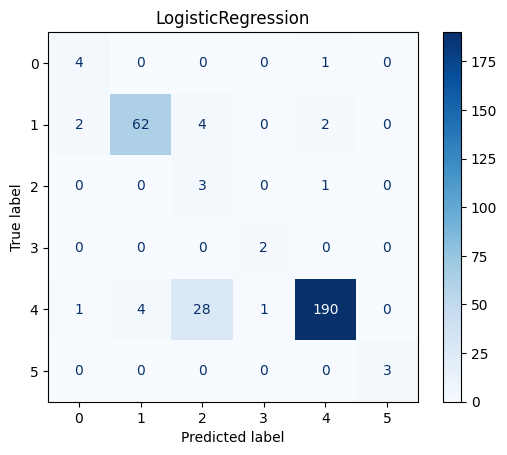

Decision Tree
DecisionTreeClassifier
Accuracy          : 0.9351
Balanced Accuracy : 0.7986
Precision         : 0.9493
Recall            : 0.9351
F1 Score          : 0.9394
MCC               : 0.8519
Cohen Kappa       : 0.8505
ROC-AUC           : 0.9179

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.92      0.93      0.92        70
           2       0.33      0.75      0.46         4
           3       1.00      0.50      0.67         2
           4       0.98      0.95      0.96       224
           5       1.00      0.67      0.80         3

    accuracy                           0.94       308
   macro avg       0.81      0.80      0.76       308
weighted avg       0.95      0.94      0.94       308



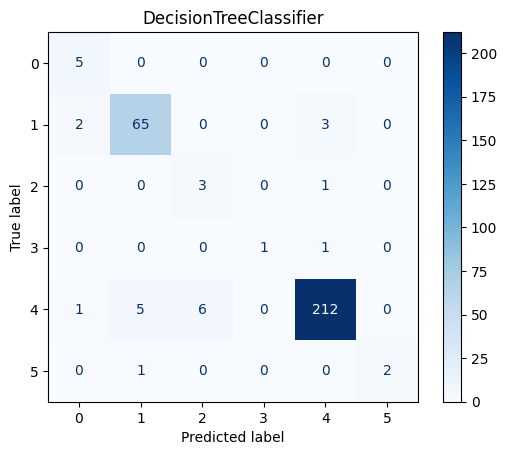

Random Forest
RandomForestClassifier
Accuracy          : 0.9545
Balanced Accuracy : 0.8595
Precision         : 0.9595
Recall            : 0.9545
F1 Score          : 0.9556
MCC               : 0.8941
Cohen Kappa       : 0.8936
ROC-AUC           : 0.9892

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.94      0.94        70
           2       0.60      0.75      0.67         4
           3       1.00      0.50      0.67         2
           4       0.98      0.96      0.97       224
           5       1.00      1.00      1.00         3

    accuracy                           0.95       308
   macro avg       0.86      0.86      0.84       308
weighted avg       0.96      0.95      0.96       308



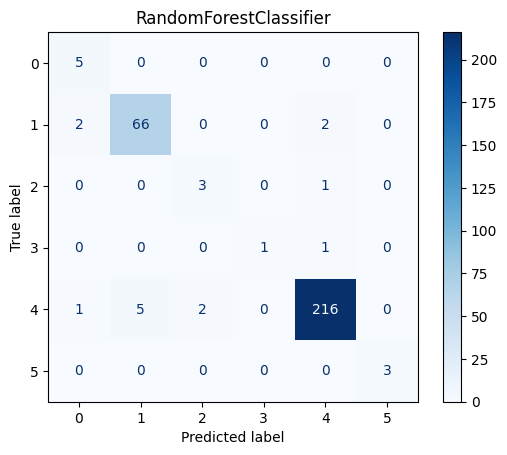

Extra Trees
ExtraTreesClassifier
Accuracy          : 0.9513
Balanced Accuracy : 0.8555
Precision         : 0.9559
Recall            : 0.9513
F1 Score          : 0.9522
MCC               : 0.8854
Cohen Kappa       : 0.8852
ROC-AUC           : 0.9884

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.91      0.92        70
           2       0.60      0.75      0.67         4
           3       1.00      0.50      0.67         2
           4       0.98      0.97      0.97       224
           5       1.00      1.00      1.00         3

    accuracy                           0.95       308
   macro avg       0.86      0.86      0.83       308
weighted avg       0.96      0.95      0.95       308



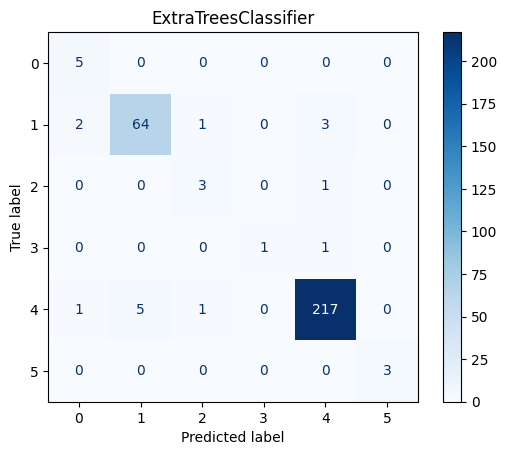

KNN
KNeighborsClassifier
Accuracy          : 0.9091
Balanced Accuracy : 0.8842
Precision         : 0.9456
Recall            : 0.9091
F1 Score          : 0.9245
MCC               : 0.8041
Cohen Kappa       : 0.7989
ROC-AUC           : 0.9547

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.90      0.89      0.89        70
           2       0.12      0.50      0.20         4
           3       1.00      1.00      1.00         2
           4       0.98      0.92      0.95       224
           5       1.00      1.00      1.00         3

    accuracy                           0.91       308
   macro avg       0.77      0.88      0.80       308
weighted avg       0.95      0.91      0.92       308



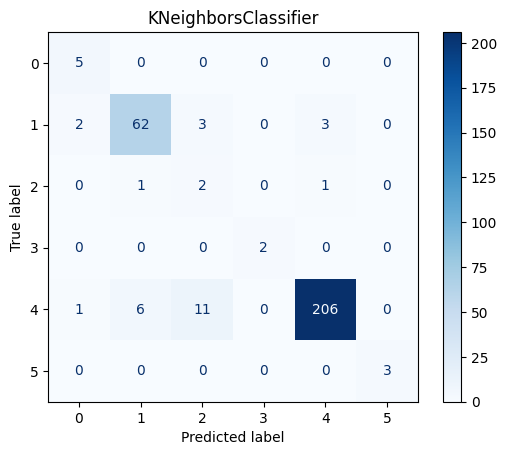

SVM
SVC
Accuracy          : 0.8994
Balanced Accuracy : 0.9278
Precision         : 0.9562
Recall            : 0.8994
F1 Score          : 0.9222
MCC               : 0.7987
Cohen Kappa       : 0.7865
ROC-AUC           : 0.9811

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.92      0.93      0.92        70
           2       0.13      0.75      0.22         4
           3       1.00      1.00      1.00         2
           4       0.99      0.89      0.94       224
           5       1.00      1.00      1.00         3

    accuracy                           0.90       308
   macro avg       0.78      0.93      0.81       308
weighted avg       0.96      0.90      0.92       308



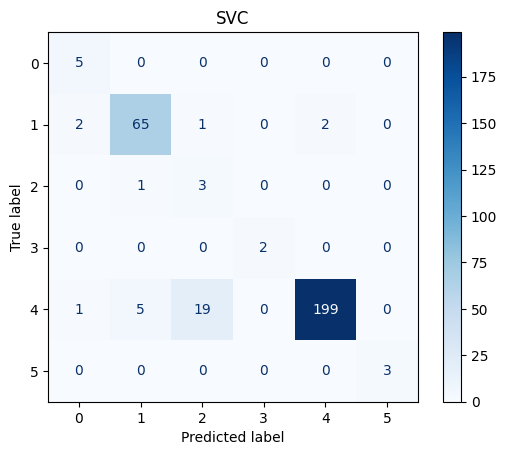

XGBoost
XGBClassifier
Accuracy          : 0.9610
Balanced Accuracy : 0.9019
Precision         : 0.9654
Recall            : 0.9610
F1 Score          : 0.9618
MCC               : 0.9093
Cohen Kappa       : 0.9088
ROC-AUC           : 0.9919

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.94      0.94        70
           2       0.80      1.00      0.89         4
           3       1.00      0.50      0.67         2
           4       0.99      0.97      0.98       224
           5       1.00      1.00      1.00         3

    accuracy                           0.96       308
   macro avg       0.89      0.90      0.87       308
weighted avg       0.97      0.96      0.96       308



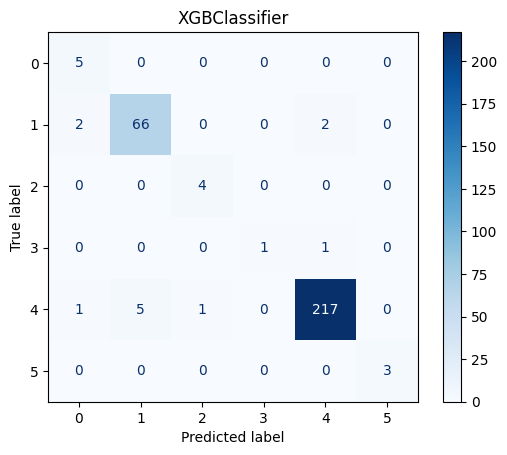

LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3064
[LightGBM] [Info] Number of data points in the train set: 5364, number of used features: 14
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

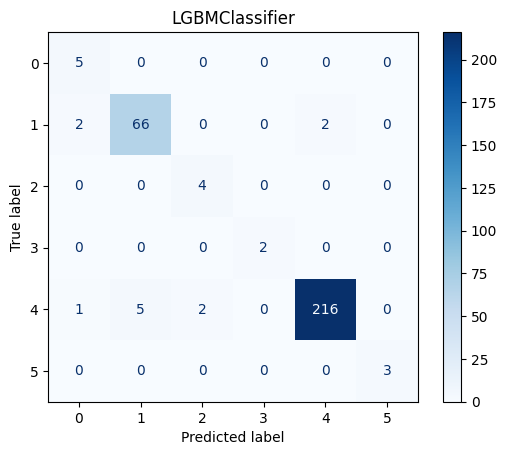

CatBoost
CatBoostClassifier
Accuracy          : 0.9448
Balanced Accuracy : 0.8025
Precision         : 0.9539
Recall            : 0.9448
F1 Score          : 0.9476
MCC               : 0.8732
Cohen Kappa       : 0.8722
ROC-AUC           : 0.9385

Classification Report

              precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       0.93      0.94      0.94        70
           2       0.43      0.75      0.55         4
           3       0.50      0.50      0.50         2
           4       0.98      0.96      0.97       224
           5       1.00      0.67      0.80         3

    accuracy                           0.94       308
   macro avg       0.74      0.80      0.75       308
weighted avg       0.95      0.94      0.95       308



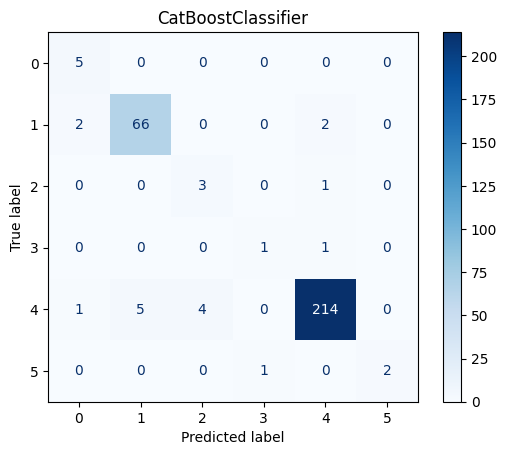

In [18]:
import warnings
warnings.filterwarnings('ignore')
!pip install catboost

# ============================================================
# TRAIN AND EVALUATE ALL MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42
        ),

    "LightGBM":
        LGBMClassifier(random_state=42),

    "CatBoost":
        CatBoostClassifier(
            verbose=0,
            random_state=42
        )
}

results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    metrics = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train_smote,
        y_test
    )

    metrics["Model"] = name

    results.append(metrics)

In [19]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("F1", ascending=False)
)

comparison = comparison.round(4)

comparison

,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,Kappa,ROC-AUC
Model,,,,,,,,
LightGBM,0.9610,0.9845,0.9669,0.9610,0.9627,0.9108,0.9098,0.9913
XGBoost,0.9610,0.9019,0.9654,0.9610,0.9618,0.9093,0.9088,0.9919
Random Forest,0.9545,0.8595,0.9595,0.9545,0.9556,0.8941,0.8936,0.9892
Extra Trees,0.9513,0.8555,0.9559,0.9513,0.9522,0.8854,0.8852,0.9884
CatBoost,0.9448,0.8025,0.9539,0.9448,0.9476,0.8732,0.8722,0.9385
Decision Tree,0.9351,0.7986,0.9493,0.9351,0.9394,0.8519,0.8505,0.9179
KNN,0.9091,0.8842,0.9456,0.9091,0.9245,0.8041,0.7989,0.9547
SVM,0.8994,0.9278,0.9562,0.8994,0.9222,0.7987,0.7865,0.9811
Logistic Regression,0.8571,0.8807,0.9502,0.8571,0.8961,0.7300,0.7092,0.9802


In [36]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=comparison)

MessageError: Error: credential propagation was unsuccessful

In [29]:

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
    # Add your tuned parameters here if you used tuning
)

xgb_model.fit(X_train_scaled, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [37]:
best_model = xgb_model
best_model_name = "XGBoost"

In [38]:
import joblib

# Save Final Model
joblib.dump(xgb_model, "Hemoglobinopathy_XGBoost_Model.pkl")

# Save Preprocessing Objects
joblib.dump(scaler, "StandardScaler.pkl")
joblib.dump(target_encoder, "Target_LabelEncoder.pkl")
joblib.dump(gender_encoder, "Gender_LabelEncoder.pkl")
joblib.dump(hospital_encoder, "Hospital_LabelEncoder.pkl")

print("="*60)
print("FILES SAVED SUCCESSFULLY")
print("="*60)

FILES SAVED SUCCESSFULLY


In [39]:
from google.colab import files

files.download("Hemoglobinopathy_XGBoost_Model.pkl")
files.download("StandardScaler.pkl")
files.download("Target_LabelEncoder.pkl")
files.download("Gender_LabelEncoder.pkl")
files.download("Hospital_LabelEncoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
# ============================================================
# FINAL PREDICTIONS
# ============================================================

y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)

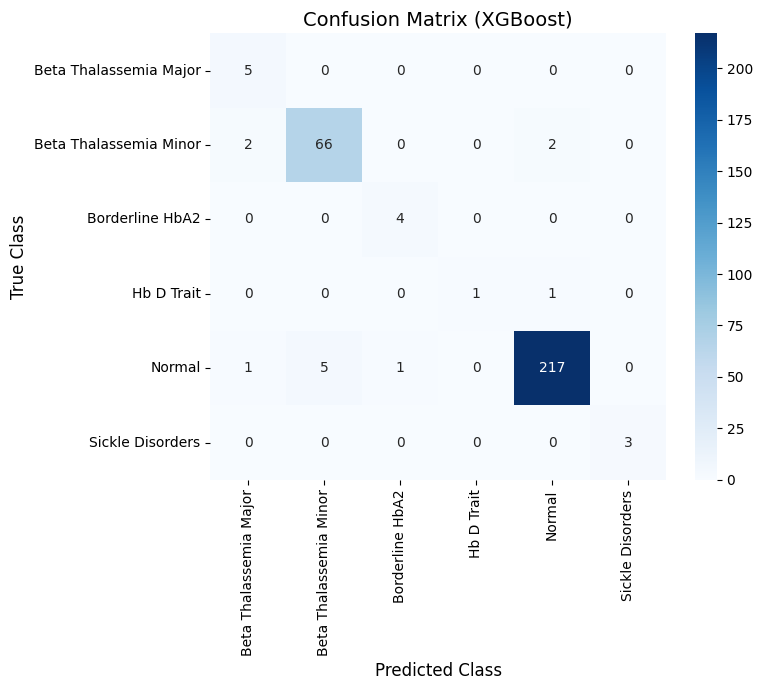

In [41]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = target_encoder.classes_

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class",fontsize=12)
plt.ylabel("True Class",fontsize=12)
plt.title("Confusion Matrix (XGBoost)",fontsize=14)

plt.tight_layout()

plt.savefig("Figure_Confusion_Matrix.png",dpi=300)

plt.show()

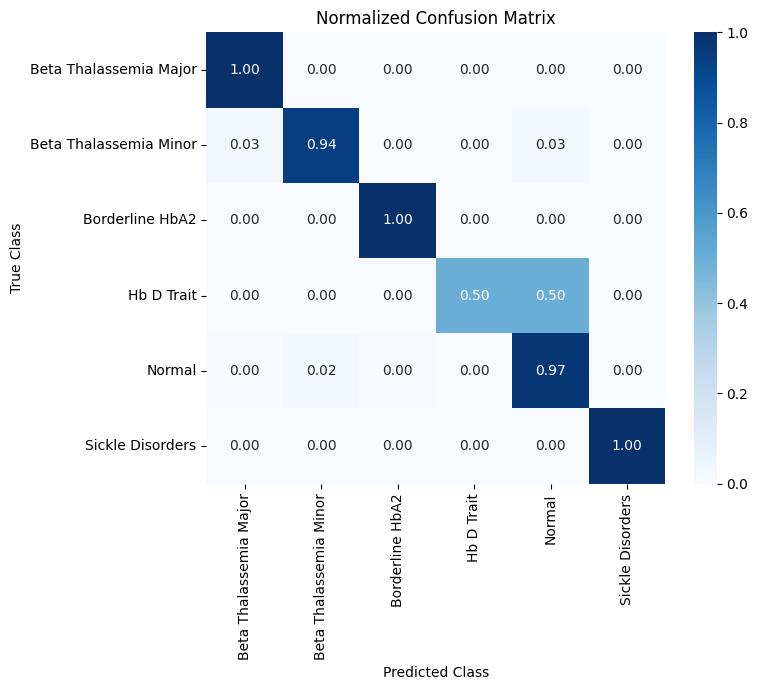

In [42]:
cm = confusion_matrix(y_test,y_pred,normalize="true")

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()

plt.savefig("Figure_Normalized_CM.png",dpi=300)

plt.show()

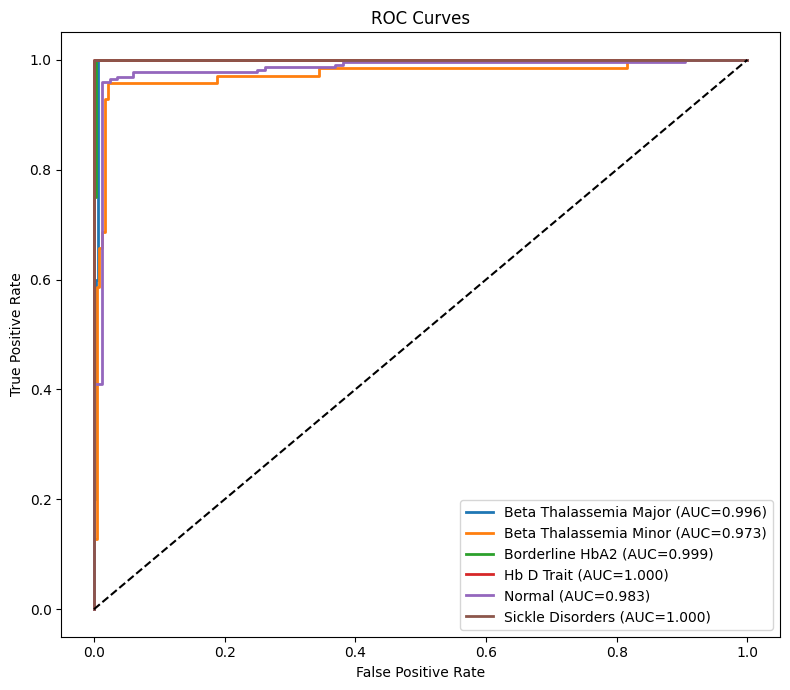

In [43]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes=np.unique(y)

y_test_bin=label_binarize(y_test,classes=classes)

plt.figure(figsize=(8,7))

for i in range(len(classes)):

    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_prob[:,i])

    roc_auc=auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{labels[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.tight_layout()

plt.savefig("Figure_ROC.png",dpi=300)

plt.show()

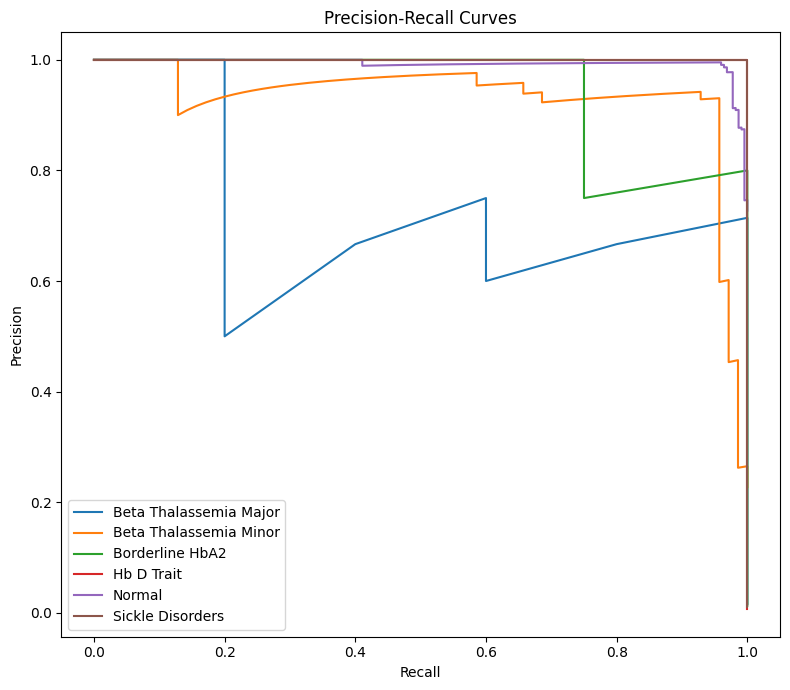

In [44]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,7))

for i in range(len(classes)):

    precision,recall,_=precision_recall_curve(
        y_test_bin[:,i],
        y_prob[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=labels[i]
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curves")

plt.legend()

plt.tight_layout()

plt.savefig("Figure_PR_Curve.png",dpi=300)

plt.show()

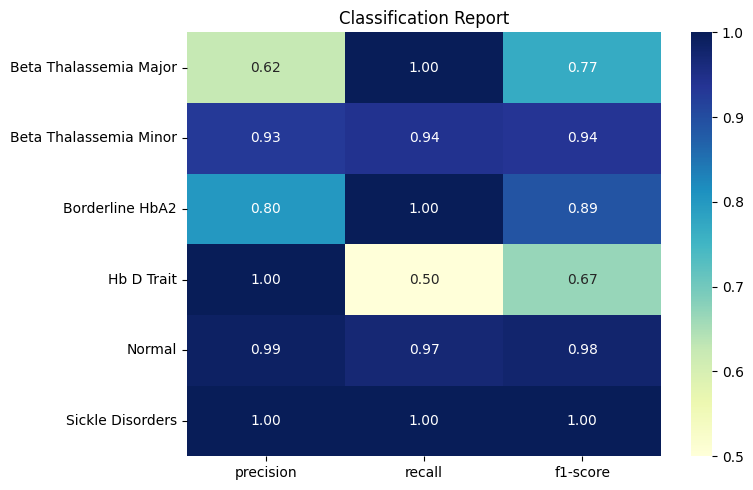

In [45]:
from sklearn.metrics import classification_report

report=classification_report(
    y_test,
    y_pred,
    target_names=labels,
    output_dict=True
)

report_df=pd.DataFrame(report).transpose()

plt.figure(figsize=(8,5))

sns.heatmap(
    report_df.iloc[:-3,:3],
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Classification Report")

plt.tight_layout()

plt.savefig("Figure_Classification_Report.png",dpi=300)

plt.show()

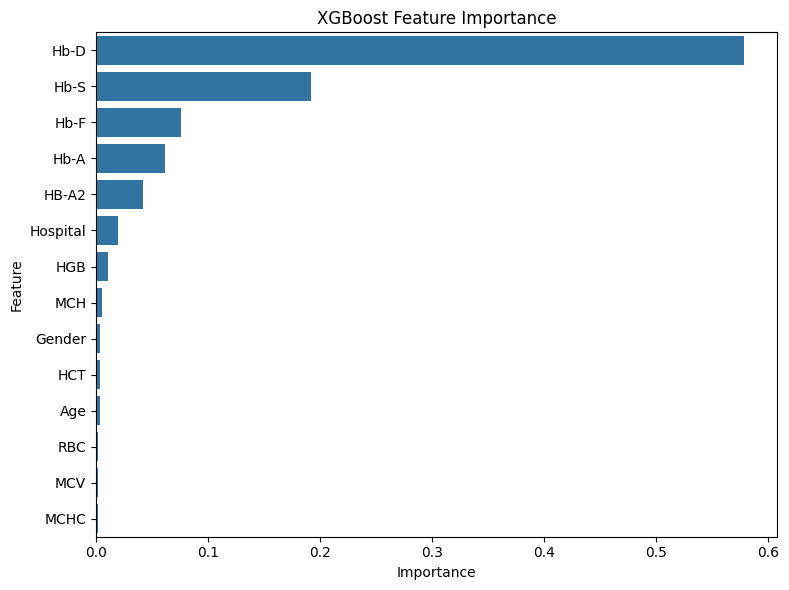

In [46]:
importance=pd.DataFrame({

"Feature":X.columns,

"Importance":xgb_model.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    y="Feature",
    x="Importance"
)

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.savefig("Figure_XGBoost_Importance.png",dpi=300)

plt.show()

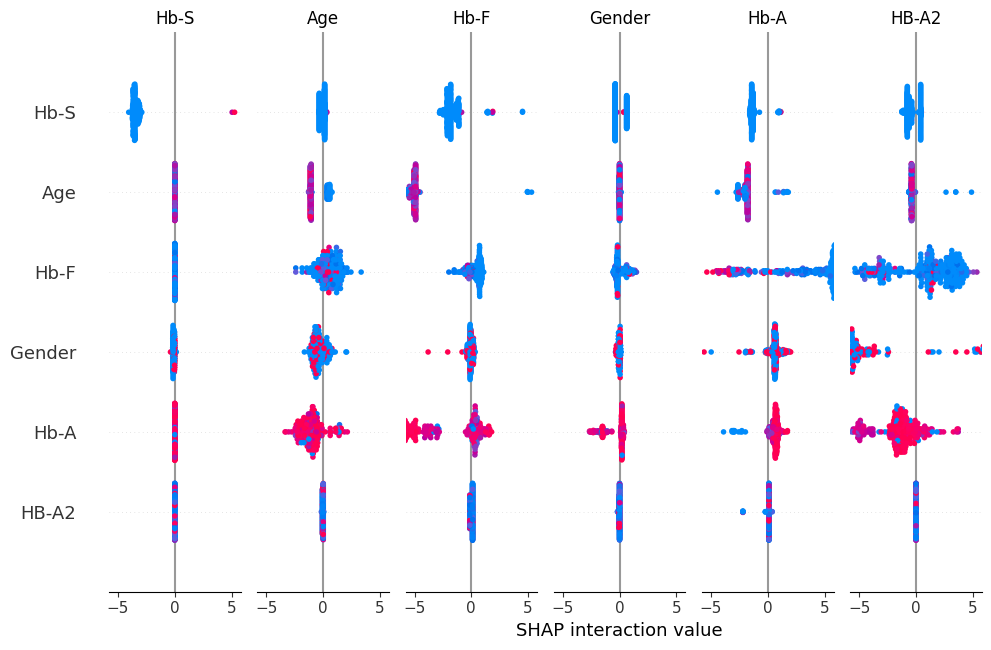

In [47]:
import shap

explainer=shap.TreeExplainer(xgb_model)

shap_values=explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test_scaled,
    show=False
)

plt.tight_layout()

plt.savefig("Figure_SHAP_Summary.png",dpi=300)

plt.show()

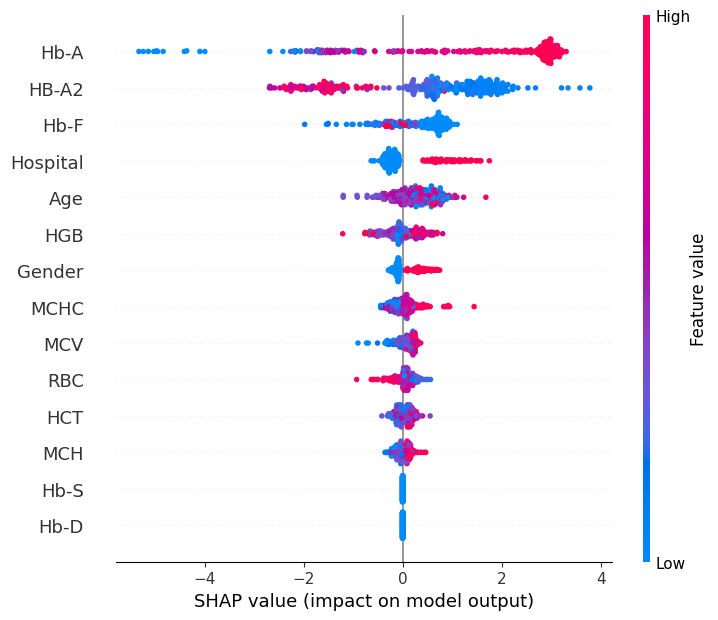

In [52]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_scaled)

class_id = 4      # Normal

shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values[:, :, class_id],
        data=X_test_scaled.values,
        feature_names=X_test_scaled.columns
    ),
    max_display=14
)

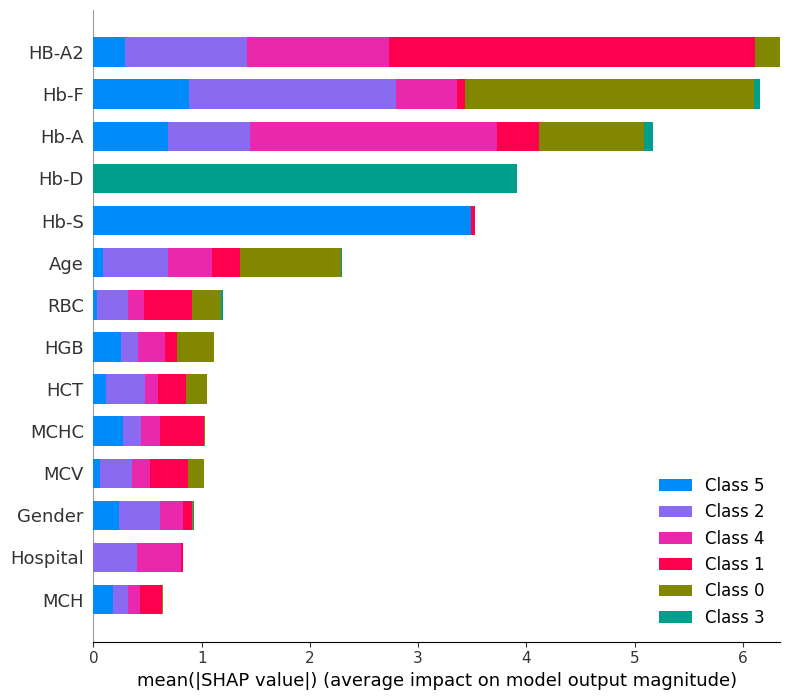

In [49]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar",
    show=False
)

plt.savefig("Figure_SHAP_Bar.png",dpi=300)

plt.show()

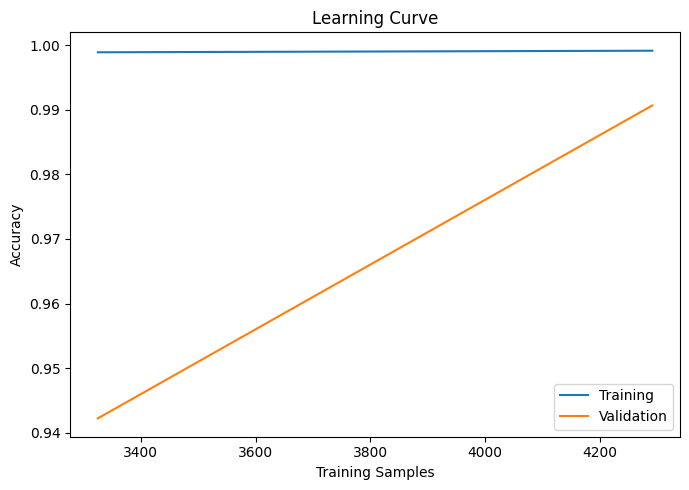

In [50]:
from sklearn.model_selection import learning_curve

train_sizes,train_scores,test_scores=learning_curve(

xgb_model,

X_train_scaled,

y_train_smote,

cv=5,

scoring="accuracy"

)

train_mean=train_scores.mean(axis=1)

test_mean=test_scores.mean(axis=1)

plt.figure(figsize=(7,5))

plt.plot(train_sizes,train_mean,label="Training")

plt.plot(train_sizes,test_mean,label="Validation")

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.legend()

plt.tight_layout()

plt.savefig("Figure_Learning_Curve.png",dpi=300)

plt.show()

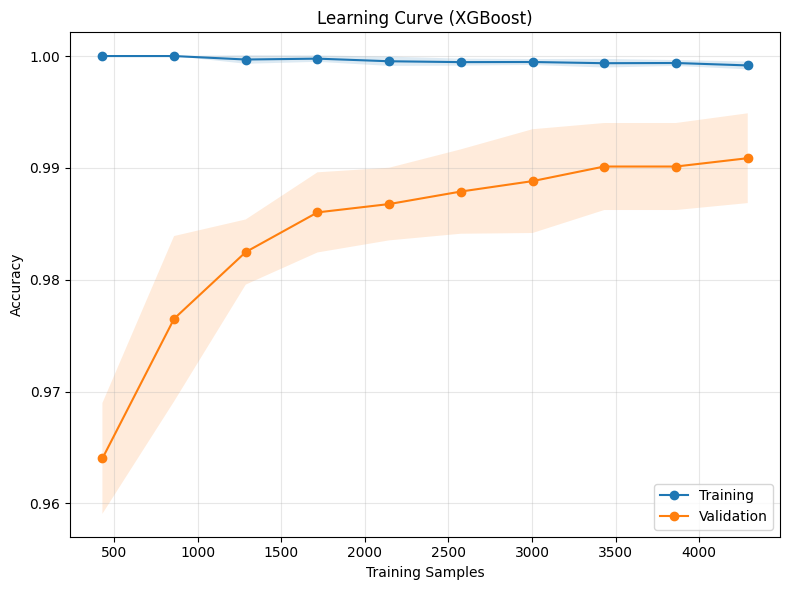

In [63]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb_model,
    X=X_train_scaled,
    y=y_train_smote,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, 'o-', label="Training")
plt.plot(train_sizes, test_mean, 'o-', label="Validation")

plt.fill_between(train_sizes,
                 train_mean-train_std,
                 train_mean+train_std,
                 alpha=0.15)

plt.fill_between(train_sizes,
                 test_mean-test_std,
                 test_mean+test_std,
                 alpha=0.15)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve (XGBoost)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("Figure_Learning_Curve.png", dpi=300)
plt.show()

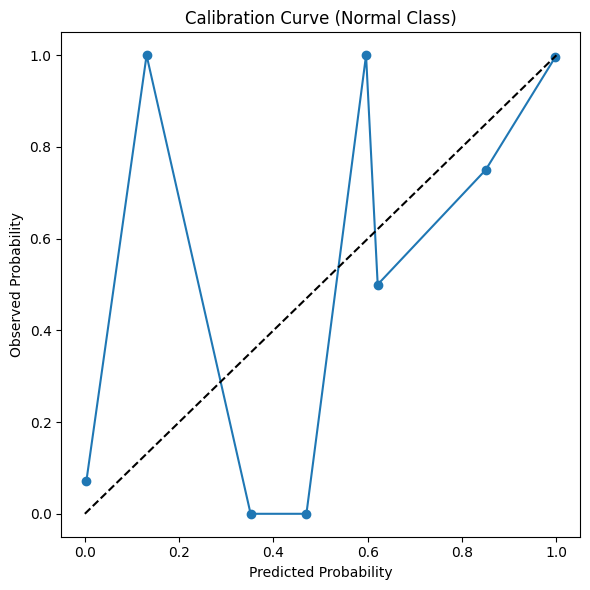

In [51]:
from sklearn.calibration import calibration_curve

prob_true,prob_pred=calibration_curve(

(y_test==4).astype(int),

y_prob[:,4],

n_bins=10

)

plt.figure(figsize=(6,6))

plt.plot(prob_pred,prob_true,marker='o')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Probability")

plt.title("Calibration Curve (Normal Class)")

plt.tight_layout()

plt.savefig("Figure_Calibration.png",dpi=300)

plt.show()

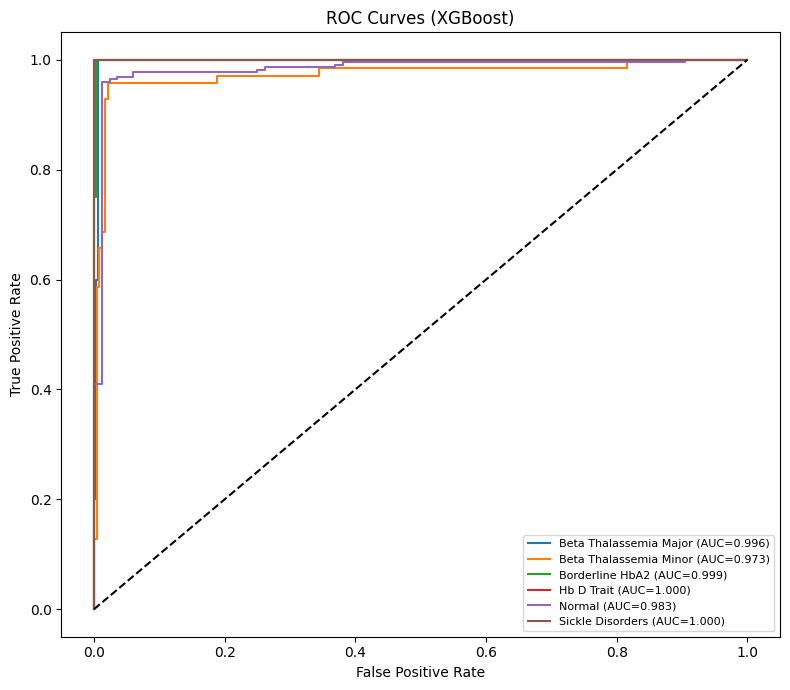

In [66]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = xgb_model.predict_proba(X_test_scaled)

y_bin = label_binarize(
    y_test,
    classes=range(len(target_encoder.classes_))
)

plt.figure(figsize=(8,7))

for i,class_name in enumerate(target_encoder.classes_):

    fpr,tpr,_=roc_curve(y_bin[:,i],y_score[:,i])

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={auc(fpr,tpr):.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (XGBoost)")
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig("Figure_ROC.png",dpi=300)
plt.show()

Final XGBoost Evaluation

                        precision    recall  f1-score   support

Beta Thalassemia Major       0.62      1.00      0.77         5
Beta Thalassemia Minor       0.93      0.94      0.94        70
       Borderline HbA2       0.80      1.00      0.89         4
            Hb D Trait       1.00      0.50      0.67         2
                Normal       0.99      0.97      0.98       224
      Sickle Disorders       1.00      1.00      1.00         3

              accuracy                           0.96       308
             macro avg       0.89      0.90      0.87       308
          weighted avg       0.97      0.96      0.96       308



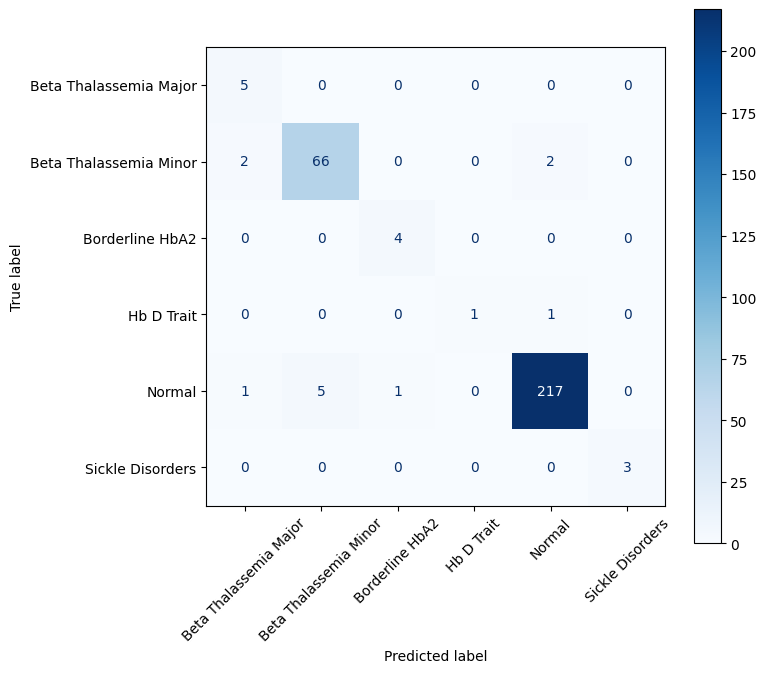

In [65]:

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Prediction
y_pred = xgb_model.predict(X_test_scaled)

# Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8,7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)

plt.tight_layout()
plt.savefig("Figure_ConfusionMatrix.png",dpi=300,bbox_inches="tight")
plt.show()

tables

Table 1 Dataset Summary

In [53]:
dataset_summary = pd.DataFrame({

"Characteristic":[
"Total Samples",
"Features",
"Classes",
"Missing Values",
"Duplicate Records"
],

"Value":[
len(df),
X.shape[1],
df.Results.nunique(),
df.isna().sum().sum(),
df.duplicated().sum()
]

})

dataset_summary

,Characteristic,Value
0,Total Samples,1539
1,Features,14
2,Classes,6
3,Missing Values,0
4,Duplicate Records,2


Table 2 Class Distribution

In [54]:
table2 = pd.DataFrame({

"Diagnosis":df.Results.value_counts().index,

"Count":df.Results.value_counts().values,

"Percentage (%)":(
df.Results.value_counts(normalize=True)*100
).round(2)

})

table2

,Diagnosis,Count,Percentage (%)
Results,,,
4,4,1118,72.64
1,1,350,22.74
2,2,22,1.43
0,0,22,1.43
5,5,17,1.10
3,3,10,0.65


Table 3 Descriptive Statistics

In [55]:
table3 = df.describe().T.round(2)

table3

,count,mean,std,min,25%,50%,75%,max
Age,1539.0,19.60,13.70,0.0,6.00,20.00,28.00,80.0
Gender,1539.0,0.39,0.49,0.0,0.00,0.00,1.00,1.0
Hb-A,1539.0,93.98,13.65,0.0,95.30,97.30,97.90,99.0
HB-A2,1539.0,2.91,1.23,0.0,2.00,2.40,3.30,9.4
Hb-F,1539.0,2.09,10.72,0.0,0.00,0.00,0.80,94.3
Hb-S,1539.0,0.39,4.30,0.0,0.00,0.00,0.00,67.0
Hb-D,1539.0,0.29,3.34,0.0,0.00,0.00,0.00,63.2
RBC,1539.0,4.84,12.65,0.0,3.95,4.54,5.15,499.0
HGB,1539.0,9.96,4.60,1.6,7.90,9.40,11.70,113.0
HCT,1539.0,33.39,8.84,5.8,27.95,32.30,38.40,86.1


Table 4 Mean Feature Values per Disease

In [56]:
table4 = (

df.groupby("Results")

.mean(numeric_only=True)

.round(2)

)

table4

,Age,Gender,Hb-A,HB-A2,Hb-F,Hb-S,Hb-D,RBC,HGB,HCT,MCV,MCH,MCHC,Hospital
Results,,,,,,,,,,,,,,
0,1.75,0.41,15.75,1.39,74.05,0.00,0.00,2.69,5.70,18.62,68.35,21.59,30.71,0.32
1,22.48,0.39,93.00,4.85,1.81,0.07,0.01,6.65,10.29,33.82,64.30,18.83,29.18,0.20
2,18.64,0.27,95.42,3.10,1.40,0.00,0.00,3.93,7.98,27.29,70.00,21.53,29.91,0.50
3,22.80,0.40,67.06,2.94,0.08,0.00,33.12,4.60,10.90,35.39,76.98,23.29,30.43,0.10
4,19.08,0.39,96.92,2.32,0.55,0.00,0.00,4.35,9.98,33.70,76.96,23.13,30.19,0.23
5,17.41,0.88,36.13,3.94,18.31,33.55,6.51,4.17,9.65,30.14,76.34,27.14,30.74,0.06


Table 5 Kruskal-Wallis Results

In [64]:
from scipy.stats import kruskal

kruskal_data = []

for feature in numerical_features:
    groups = [X[feature][y == cls] for cls in np.unique(y)]
    h_statistic, p_value = kruskal(*groups)
    kruskal_data.append({"Feature": feature, "H Statistic": h_statistic, "P-value": p_value})

kruskal_results = pd.DataFrame(kruskal_data)

kruskal_results.sort_values(
"H Statistic",
ascending=False
)

,Feature,H Statistic,P-value
5,Hb-D,1122.248029,2.032588e-240
4,Hb-S,1089.620044,2.365595e-233
2,HB-A2,813.385864,1.470173e-173
1,Hb-A,774.823743,3.231957e-165
6,RBC,269.887070,2.959224e-56
9,MCV,260.986644,2.411010e-54
3,Hb-F,181.750014,2.262898e-37
10,MCH,178.030124,1.409634e-36
8,HCT,61.619682,5.621102e-12
0,Age,60.625735,9.024045e-12


Table 6 Feature Importance

In [58]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":xgb_model.feature_importances_

})

importance=importance.sort_values(

"Importance",

ascending=False

)

importance

,Feature,Importance
6,Hb-D,0.578773
5,Hb-S,0.191445
4,Hb-F,0.076055
2,Hb-A,0.061231
3,HB-A2,0.041761
13,Hospital,0.019260
8,HGB,0.010666
11,MCH,0.004949
1,Gender,0.003892
9,HCT,0.003374


Table 8 Classification Report

In [59]:
from sklearn.metrics import classification_report

report = classification_report(

y_test,

y_pred,

target_names=target_encoder.classes_,

output_dict=True

)

table8 = pd.DataFrame(report).transpose()

table8

,precision,recall,f1-score,support
Beta Thalassemia Major,0.625000,1.000000,0.769231,5.000000
Beta Thalassemia Minor,0.929577,0.942857,0.936170,70.000000
Borderline HbA2,0.800000,1.000000,0.888889,4.000000
Hb D Trait,1.000000,0.500000,0.666667,2.000000
Normal,0.986364,0.968750,0.977477,224.000000
Sickle Disorders,1.000000,1.000000,1.000000,3.000000
accuracy,0.961039,0.961039,0.961039,0.961039
macro avg,0.890157,0.901935,0.873072,308.000000
weighted avg,0.965392,0.961039,0.961759,308.000000


Table 9 Confusion Matrix

In [60]:
cm = pd.DataFrame(

confusion_matrix(y_test,y_pred),

index=target_encoder.classes_,

columns=target_encoder.classes_

)

cm

,Beta Thalassemia Major,Beta Thalassemia Minor,Borderline HbA2,Hb D Trait,Normal,Sickle Disorders
Beta Thalassemia Major,5,0,0,0,0,0
Beta Thalassemia Minor,2,66,0,0,2,0
Borderline HbA2,0,0,4,0,0,0
Hb D Trait,0,0,0,1,1,0
Normal,1,5,1,0,217,0
Sickle Disorders,0,0,0,0,0,3


Table 10 Hyperparameters

In [61]:
params = pd.DataFrame({

"Hyperparameter":[
"n_estimators",
"learning_rate",
"max_depth",
"subsample",
"colsample_bytree",
"gamma",
"min_child_weight"
],

"Value":[
xgb_model.get_params()["n_estimators"],
xgb_model.get_params()["learning_rate"],
xgb_model.get_params()["max_depth"],
xgb_model.get_params()["subsample"],
xgb_model.get_params()["colsample_bytree"],
xgb_model.get_params()["gamma"],
xgb_model.get_params()["min_child_weight"]
]

})

params

,Hyperparameter,Value
0,n_estimators,None
1,learning_rate,None
2,max_depth,None
3,subsample,None
4,colsample_bytree,None
5,gamma,None
6,min_child_weight,None


Table 11 Per-Class ROC-AUC

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

classes=np.unique(y)

y_bin=label_binarize(y_test,classes=classes)

auc_scores=[]

for i,name in enumerate(target_encoder.classes_):

    auc_scores.append(

        roc_auc_score(

            y_bin[:,i],

            y_prob[:,i]

        )

    )

table11=pd.DataFrame({

"Class":target_encoder.classes_,

"ROC-AUC":np.round(auc_scores,4)

})

table11

,Class,ROC-AUC
0,Beta Thalassemia Major,0.9960
1,Beta Thalassemia Minor,0.9732
2,Borderline HbA2,0.9992
3,Hb D Trait,1.0000
4,Normal,0.9830
5,Sickle Disorders,1.0000
